# Sparkles training console (simple)

Interactive wrapper around the same Python APIs as the CLI. Edit **parameters** below, then run **single-train** or **grid-search** cells.

**Setup** (once, from repo root):

```bash
pip install -e ".[dev,notebook,ml]"   # ml = XGBoost
jupyter notebook notebooks/sparkles_train_console.ipynb
```

After `pip install` or pulling new code: **Kernel → Restart**.

**Config cells:** `CONFIG_PATH` = full experiment under `configs/experiments/` (has `symbol`, dates, barriers). **`presets/`** files are overlays only — set `PRESET_PATH`, not `CONFIG_PATH`, to those.

**Run modes** (set `RUN_MODE` in the parameters cell):

| Mode | What to run |
|------|-------------|
| `"single"` | Dry-run → Train cells (one experiment via `OVERRIDES`) |
| `"grid"` | Grid preview → Grid train cells (cartesian sweep via inline `GRID_SPEC` or `GRID_YAML_PATH`) |

Grid uses dotted paths like `model.xgb_learning_rate` — same as `scripts/run_grid_search.py`. All runs append to **`experiments.jsonl`**; the **All trials** and **Top 10 leaderboard** cells at the bottom rank runs by **`val_f1_macro`**.

Prerequisites: `sparkles ingest` and `sparkles label` for **`CONFIG_PATH`** (same as CLI).

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import pandas as pd

# Repo root (parent of notebooks/)
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "sparkles").is_dir():
    REPO_ROOT = Path.cwd().parent
if not (REPO_ROOT / "sparkles").is_dir():
    raise RuntimeError("Open this notebook from the Sparkles repo root or notebooks/ folder")

import os
os.chdir(REPO_ROOT)

# Prefer repo source over a stale site-packages install (then restart kernel once).
_repo_src = str((REPO_ROOT / "sparkles").resolve().parent)
if _repo_src not in sys.path:
    sys.path.insert(0, _repo_src)

from sparkles.env import load_dotenv
load_dotenv()

import sparkles
from sparkles.config.schema import FeatureConfig

# If you added G1/G2 features in OVERRIDES but this fails, restart the kernel after:
#   pip install -e ".[dev,notebook,ml]"
_g1_fields = ("returns_multi_horizon", "realized_vol_multi", "range_vol_multi")
_g2_fields = ("session_time", "volume_context", "volume_median_window_bars", "vwap_distance")
_g3_fields = ("bar_microstructure", "market_context", "market_spy_return_bars")
_g4_fields = ("technical_indicators", "ema_windows_bars", "rsi_window_bars", "macd_fast_bars", "session_day_of_week", "order_flow_proxies", "roll_window_bars")
_has_g1_schema = all(f in FeatureConfig.model_fields for f in _g1_fields)
_has_g2_schema = all(f in FeatureConfig.model_fields for f in _g2_fields)
_has_g3_schema = all(f in FeatureConfig.model_fields for f in _g3_fields)
_has_g4_schema = all(f in FeatureConfig.model_fields for f in _g4_fields)

print("Working directory:", REPO_ROOT.resolve())
print("sparkles loaded from:", Path(sparkles.__file__).resolve())
print("TWELVEDATA_API_KEY loaded:", bool(os.environ.get("TWELVEDATA_API_KEY", "").strip()))
print("Phase G1 schema:", "OK" if _has_g1_schema else "MISSING — run pip install -e . and Restart Kernel")
print("Phase G2 schema:", "OK" if _has_g2_schema else "MISSING — run pip install -e . and Restart Kernel")
print("Phase G3 schema:", "OK" if _has_g3_schema else "MISSING — run pip install -e . and Restart Kernel")
print("Phase G4 schema:", "OK" if _has_g4_schema else "MISSING — run pip install -e . and Restart Kernel")

Working directory: C:\Users\micha\PyProjects\Sparkles
sparkles loaded from: C:\Users\micha\PyProjects\Sparkles\sparkles\__init__.py
TWELVEDATA_API_KEY loaded: True
Phase G1 schema: OK
Phase G2 schema: OK
Phase G3 schema: OK
Phase G4 schema: OK


In [ ]:
# --- Edit these knobs ---
# Full experiment YAML (symbol, dates, barriers, stride) — NOT a presets/ overlay file.
CONFIG_PATH = REPO_ROOT / "configs/experiments/rklb_daytrade_v3.yaml"
# Optional preset merged on top of CONFIG_PATH (train/features/model tweaks). None = skip.
# G4a A/B: PRESET_PATH = REPO_ROOT / "configs/experiments/presets/rklb_daytrade_v3_g4a.yaml"
PRESET_PATH: Path | None = REPO_ROOT / "configs/experiments/presets/rklb_daytrade_v3_g4c.yaml"  # None = base v3 only
# G4b A/B: PRESET_PATH = REPO_ROOT / "configs/experiments/presets/rklb_daytrade_v3_g4b.yaml"
# Merged last — overrides preset where keys overlap. Tune model: / preprocess: here.
OVERRIDES: dict = {
    "train": {
        "experiment_name": "Sparkles_v1.1.9",
        "notes": "New V3 YAML and drop much wider spread, .05 loss and .1 top,6 step label stride",
        "export_predictions": "val",
    },
    "model": {
        "type": "xgboost_classifier",
        "random_seed": 42,
        # "class_weight": "balanced",
        # "xgb_max_depth": 3,
        # "xgb_n_estimators": 255,
        # "xgb_learning_rate": 0.02,
        # "xgb_subsample": 0.8,
        # "xgb_colsample_bytree": 0.8,
    },
    "preprocess": {
        "scaler": "none",
    },
    "features": {
        "returns_multi_horizon": True,
        "realized_vol_multi": True,
        "range_vol_multi": True,
        "returns_horizons_bars": [1, 5, 10, 15, 30, 60],
        "realized_vol_windows_bars": [5, 10, 15, 30],
        "realized_vol_include_ratio": True,
        "range_vol_window_bars": 15,
        "range_vol_include_atr_norm": True,
        # G2 — set True to A/B vs G1-only (or use PRESET_PATH = .../rklb_daytrade_g1_g2_v1.yaml)
        #"session_time": True,
        #"volume_context": True,
        #"volume_median_window_bars": 60,
        #"vwap_distance": True,
        # G3 — bar microstructure is OHLC-only; market_context needs sparkles ingest (SPY/VIX)
        #"bar_microstructure": True,
        #"market_context": True,
        #"market_spy_return_bars": 30,
        # G4a — technical indicators (or use preset rklb_daytrade_v3_g4a.yaml)
        #"technical_indicators": True,
        #"ema_windows_bars": [9, 21, 50],
        #"rsi_window_bars": 14,
        #"macd_fast_bars": 12,
        #"macd_slow_bars": 26,
        #"macd_signal_bars": 9,
        # G4b — weekday seasonality (or use preset rklb_daytrade_v3_g4b.yaml)
        #"session_day_of_week": True,
        # G4c — OHLCV spread/illiquidity proxies (no L2; preset rklb_daytrade_v3_g4c.yaml)
        #"order_flow_proxies": True,
        #"roll_window_bars": 20,
        #"amihud_window_bars": 20,
    },
}

DO_DRY_RUN = True   # check splits / class balance
DO_TRAIN = True     # set False to skip fit

# --- Run mode: "single" (one train) or "grid" (cartesian sweep) ---
RUN_MODE = "single"  # "single" | "grid"

# Grid search (when RUN_MODE == "grid") — uses same CONFIG_PATH + PRESET_PATH as single run
GRID_FROM_YAML = True
GRID_YAML_PATH = REPO_ROOT / "configs/experiments/grids/rklb_daytrade_xgb_v3_refit.yaml"
GRID_SPEC: dict = {
    "experiment_name_prefix": "V1.2.0",
    "notes_prefix": "sGrid",
    "fixed": {"train.export_predictions": "none"},  # faster grids; set "val" for backtest follow-up
    "params": {
        #"model.xgb_n_estimators": [60, 127, 255],
        #"model.xgb_learning_rate": [0.02, 0.08],
        #"model.xgb_max_depth": [3, 4],
        # "features.market_spy_return_bars": [5, 15, 30],
        # "train.sample_weight_method": ["none", "uniqueness"],
    },
}
DO_GRID_DRY_RUN = False   # preview each combo → dry_run_log.txt + dry_run_summary.csv
DO_GRID_TRAIN = True   # set True to fit all combinations (~seconds each)
GRID_PROGRESS_EVERY = 100  # notebook/CLI progress line every N combos

In [3]:
from sparkles.config.load import (
    deep_merge_mappings,
    load_experiment_config,
    load_experiment_config_merged,
)
from sparkles.config.schema import ExperimentConfig
from sparkles.data.ingest import resolve_symbol_parquet_path
from sparkles.labels.triple_barrier import resolve_labeled_parquet_path

_cfg_parts = str(CONFIG_PATH).replace("\\", "/").split("/")
if "presets" in _cfg_parts:
    raise ValueError(
        "CONFIG_PATH must be a full experiment YAML (e.g. configs/experiments/rklb_daytrade_v3.yaml), "
        f"not a preset overlay.\n"
        f"  You have: {CONFIG_PATH}\n"
        f"  Set PRESET_PATH to that file instead and point CONFIG_PATH at rklb_daytrade_v3.yaml."
    )

if PRESET_PATH is not None:
    cfg = load_experiment_config_merged(CONFIG_PATH, PRESET_PATH)
else:
    cfg = load_experiment_config(CONFIG_PATH)

if OVERRIDES:
    merged = deep_merge_mappings(cfg.model_dump(mode="json"), OVERRIDES)
    cfg = ExperimentConfig.model_validate(merged)

ingest_path = resolve_symbol_parquet_path(cfg, cfg.symbol, "1min", base_dir=REPO_ROOT)
label_path = resolve_labeled_parquet_path(cfg, base_dir=REPO_ROOT)

print(f"symbol={cfg.symbol}  model.type={cfg.model.type}")
print(f"barriers: TP={cfg.profit_barrier_base} SL={cfg.stop_loss_base} vertical_days={cfg.vertical_max_trading_days} stride={cfg.label_entry_stride}")
print(f"train={cfg.train_start}..{cfg.train_end}  val={cfg.val_start}..{cfg.val_end}")
print(f"experiment_name={cfg.train.experiment_name!r}")
print(f"label_cache_suffix={cfg.label_cache_suffix!r}")
print()
print(f"ingest cache:  exists={ingest_path.is_file()}  {ingest_path}")
print(f"labeled cache: exists={label_path.is_file()}  {label_path}")

if not ingest_path.is_file() or not label_path.is_file():
    print(
        "\nMissing data — run once from repo root:\n"
        f'  sparkles ingest -c "{CONFIG_PATH}" -v\n'
        f'  sparkles label  -c "{CONFIG_PATH}"\n'
        "Labeling can take several minutes. Then re-run the dry-run cell."
    )

symbol=RKLB  model.type=xgboost_classifier
barriers: TP=0.1 SL=0.05 vertical_days=3 stride=6
train=2022-01-01..2026-01-01  val=2026-01-02..2026-05-23
experiment_name='Sparkles_v1.1.9'
label_cache_suffix='dt_v2'

ingest cache:  exists=True  c:\Users\micha\PyProjects\Sparkles\data\cache\RKLB_1min.parquet
labeled cache: exists=True  c:\Users\micha\PyProjects\Sparkles\data\cache\RKLB_labeled_2022-01-01_2026-06-25_s6_dt_v2.parquet


## Single run

Set **`RUN_MODE = "single"`**. Tune **`OVERRIDES`** (or **`PRESET_PATH`**) in the parameters cell, then dry-run and train below.

In [4]:
from sparkles.models.train import dry_run_train, format_dry_run_report, run_train

if RUN_MODE != "single":
    print('Single-run dry-run skipped (RUN_MODE="grid")')
elif DO_DRY_RUN:
    report = dry_run_train(cfg)
    print(format_dry_run_report(report))
    if not report.ready:
        print("\nDry-run not ready — fix prerequisites above, then re-run this cell.")
else:
    print("Dry-run skipped (DO_DRY_RUN=False)")

Single-run dry-run skipped (RUN_MODE="grid")


In [5]:
last_run_dir: Path | None = None
grid_df: pd.DataFrame | None = None
grid_pairs: list = []

if RUN_MODE != "single":
    print('Single-run train skipped (RUN_MODE="grid")')
elif DO_TRAIN:
    last_run_dir = run_train(cfg)
    metrics = json.loads((last_run_dir / "metrics.json").read_text(encoding="utf-8"))
    print("Saved:", last_run_dir.resolve())
    print(
        f"model_type={metrics['model_type']}  "
        f"train_acc={metrics['train_accuracy']:.4f}  "
        f"val_acc={metrics['val_accuracy']:.4f}  "
        f"val_f1_macro={metrics.get('val_f1_macro', 0):.4f}  "
        f"val_f1_weighted={metrics.get('val_f1_weighted', 0):.4f}  "
        f"train_n={metrics['train_n']}  val_n={metrics['val_n']}"
    )
else:
    print("Train skipped (DO_TRAIN=False)")

Single-run train skipped (RUN_MODE="grid")


## Grid search

Set **`RUN_MODE = "grid"`** in the parameters cell. Edit **`GRID_SPEC`** (inline dict) or set **`GRID_FROM_YAML = True`**.

Each grid session writes a **timestamped folder** under **`artifacts/grid_search/`**:

| File | When |
|------|------|
| **`dry_run_log.txt`** | Verbose per-combo dry-run output |
| **`dry_run_summary.csv`** | One row per combo (`ready`, row counts, grid params) |
| **`train_log.txt`** | One line per trained combo |
| **`results.csv`** | Metrics table sorted by `val_f1_macro` |

The notebook prints **progress only** (`[i/n]`). Open the log/CSV files for details.

In [6]:
from sparkles.config.grid import build_grid_configs, load_grid_spec
from sparkles.config.grid_runner import (
    default_progress,
    new_grid_run_dir,
    run_grid_dry_run,
    write_grid_meta,
)

grid_run_dir: Path | None = None
grid_df: pd.DataFrame | None = None
grid_pairs: list = []

if RUN_MODE != "grid":
    print('Grid preview skipped (RUN_MODE="single")')
else:
    if GRID_FROM_YAML:
        grid_spec = load_grid_spec(GRID_YAML_PATH)
        spec_label = GRID_YAML_PATH.name
    else:
        grid_spec = GRID_SPEC
        spec_label = "inline GRID_SPEC"

    grid_pairs = build_grid_configs(
        grid_spec,
        base_path=CONFIG_PATH,
        preset_path=PRESET_PATH,
    )
    prefix = str(
        grid_spec.get("experiment_name_prefix")
        or grid_spec.get("grid_name")
        or "nb_grid",
    )
    grid_run_dir = new_grid_run_dir(REPO_ROOT / "artifacts" / "grid_search", prefix=prefix)
    write_grid_meta(
        grid_run_dir,
        {
            "grid_spec": spec_label,
            "base": str(CONFIG_PATH.resolve()),
            "preset": str(PRESET_PATH.resolve()) if PRESET_PATH else None,
            "n_combinations": len(grid_pairs),
            "phase": "dry_run" if DO_GRID_DRY_RUN else "preview_only",
        },
    )

    preset_name = PRESET_PATH.name if PRESET_PATH is not None else "(none)"
    print(
        f"Grid: {len(grid_pairs)} combination(s)\n"
        f"  base={CONFIG_PATH.name}  preset={preset_name}\n"
        f"  output={grid_run_dir.resolve()}"
    )

    if DO_GRID_DRY_RUN:
        grid_df, ready_n = run_grid_dry_run(
            grid_pairs,
            grid_run_dir,
            base_dir=REPO_ROOT,
            progress_every=GRID_PROGRESS_EVERY,
            progress=default_progress,
        )
        print(f"\nDry-run ready: {ready_n}/{len(grid_pairs)}")
        print(f"  log: {grid_run_dir / 'dry_run_log.txt'}")
        print(f"  csv: {grid_run_dir / 'dry_run_summary.csv'}")
        display(grid_df.head(10))
    else:
        print("Grid dry-run skipped (DO_GRID_DRY_RUN=False)")

Grid: 48 combination(s)
  base=rklb_daytrade_v3.yaml  preset=rklb_daytrade_v3_g4c.yaml
  output=C:\Users\micha\PyProjects\Sparkles\artifacts\grid_search\20260627T054124_543943Z_grid_v3_refit
Grid dry-run skipped (DO_GRID_DRY_RUN=False)


In [7]:
from sparkles.config.grid_runner import run_grid_train, write_grid_meta

if RUN_MODE != "grid":
    print('Grid train skipped (RUN_MODE="single")')
elif not DO_GRID_TRAIN:
    print("Grid train skipped (DO_GRID_TRAIN=False)")
else:
    if GRID_FROM_YAML:
        grid_spec = load_grid_spec(GRID_YAML_PATH)
    else:
        grid_spec = GRID_SPEC

    if not grid_pairs:
        grid_pairs = build_grid_configs(
            grid_spec,
            base_path=CONFIG_PATH,
            preset_path=PRESET_PATH,
        )

    if grid_run_dir is None:
        prefix = str(
            grid_spec.get("experiment_name_prefix")
            or grid_spec.get("grid_name")
            or "nb_grid"
        )
        grid_run_dir = new_grid_run_dir(
            REPO_ROOT / "artifacts" / "grid_search",
            prefix=prefix,
        )
        write_grid_meta(
            grid_run_dir,
            {
                "grid_spec": GRID_YAML_PATH.name if GRID_FROM_YAML else "inline GRID_SPEC",
                "base": str(CONFIG_PATH.resolve()),
                "preset": str(PRESET_PATH.resolve()) if PRESET_PATH else None,
                "n_combinations": len(grid_pairs),
                "phase": "train",
            },
        )
        print(f"Output: {grid_run_dir.resolve()}")

    grid_df, best = run_grid_train(
        grid_pairs,
        grid_run_dir,
        base_dir=REPO_ROOT,
        progress_every=GRID_PROGRESS_EVERY,
        progress=default_progress,
    )

    if best:
        last_run_dir = Path(str(best["run_dir"]))
        print(
            f"\nBest val_f1_macro={best['val_f1_macro']:.4f}  "
            f"run_id={best['run_id']}"
        )

    print(f"  log: {grid_run_dir / 'train_log.txt'}")
    print(f"  csv: {grid_run_dir / 'results.csv'}")

    display_cols = [
        c
        for c in grid_df.columns
        if c.startswith("grid.")
        or c
        in (
            "ok",
            "val_f1_macro",
            "val_f1_weighted",
            "val_accuracy",
            "elapsed_s",
            "run_id",
            "experiment_name",
            "error",
        )
    ]
    display(grid_df[display_cols].head(20))

[1/48] (2.1%)  grid_v3_refit_xgb_colsample_bytree0p6_xgb_learning_rate0p015
[48/48] (100.0%)  grid_v3_refit_xgb_colsample_bytree0p7_xgb_learning_rate0p015

Best val_f1_macro=0.4791  run_id=20260627T054325_076358Z
  log: c:\Users\micha\PyProjects\Sparkles\artifacts\grid_search\20260627T054124_543943Z_grid_v3_refit\train_log.txt
  csv: c:\Users\micha\PyProjects\Sparkles\artifacts\grid_search\20260627T054124_543943Z_grid_v3_refit\results.csv


,grid.model.xgb_colsample_bytree,grid.model.xgb_learning_rate,grid.model.xgb_max_depth,grid.model.xgb_n_estimators,grid.model.xgb_subsample,ok,val_f1_macro,val_f1_weighted,val_accuracy,elapsed_s,experiment_name,run_id,error
28,0.6,0.015,4,255,0.8,True,0.479133,0.572328,0.607400,5.353,grid_v3_refit_xgb_colsample_bytree0p6_xgb_lear...,20260627T054325_076358Z,
37,0.7,0.015,6,255,0.6,True,0.475481,0.573708,0.609969,7.765,grid_v3_refit_xgb_colsample_bytree0p7_xgb_lear...,20260627T054423_417935Z,
34,0.6,0.015,5,255,0.8,True,0.474476,0.571356,0.608770,6.242,grid_v3_refit_xgb_colsample_bytree0p6_xgb_lear...,20260627T054401_964929Z,
31,0.7,0.015,5,255,0.6,True,0.471606,0.562274,0.599349,6.443,grid_v3_refit_xgb_colsample_bytree0p7_xgb_lear...,20260627T054343_280088Z,
29,0.7,0.015,4,255,0.8,True,0.471360,0.563780,0.601576,5.401,grid_v3_refit_xgb_colsample_bytree0p7_xgb_lear...,20260627T054330_476322Z,
24,0.6,0.015,4,255,0.6,True,0.470707,0.562051,0.600377,5.493,grid_v3_refit_xgb_colsample_bytree0p6_xgb_lear...,20260627T054303_166166Z,
27,0.7,0.015,4,255,0.7,True,0.469295,0.564489,0.602946,5.569,grid_v3_refit_xgb_colsample_bytree0p7_xgb_lear...,20260627T054319_722323Z,
25,0.7,0.015,4,255,0.6,True,0.468284,0.559928,0.597807,5.566,grid_v3_refit_xgb_colsample_bytree0p7_xgb_lear...,20260627T054308_723331Z,
11,0.7,0.015,5,127,0.8,True,0.468006,0.539432,0.579993,3.269,grid_v3_refit_xgb_colsample_bytree0p7_xgb_lear...,20260627T054202_615206Z,
30,0.6,0.015,5,255,0.6,True,0.467639,0.564208,0.603118,6.357,grid_v3_refit_xgb_colsample_bytree0p6_xgb_lear...,20260627T054336_831314Z,


C:\Users\micha\AppData\Local\Temp\ipykernel_25032\3924406515.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


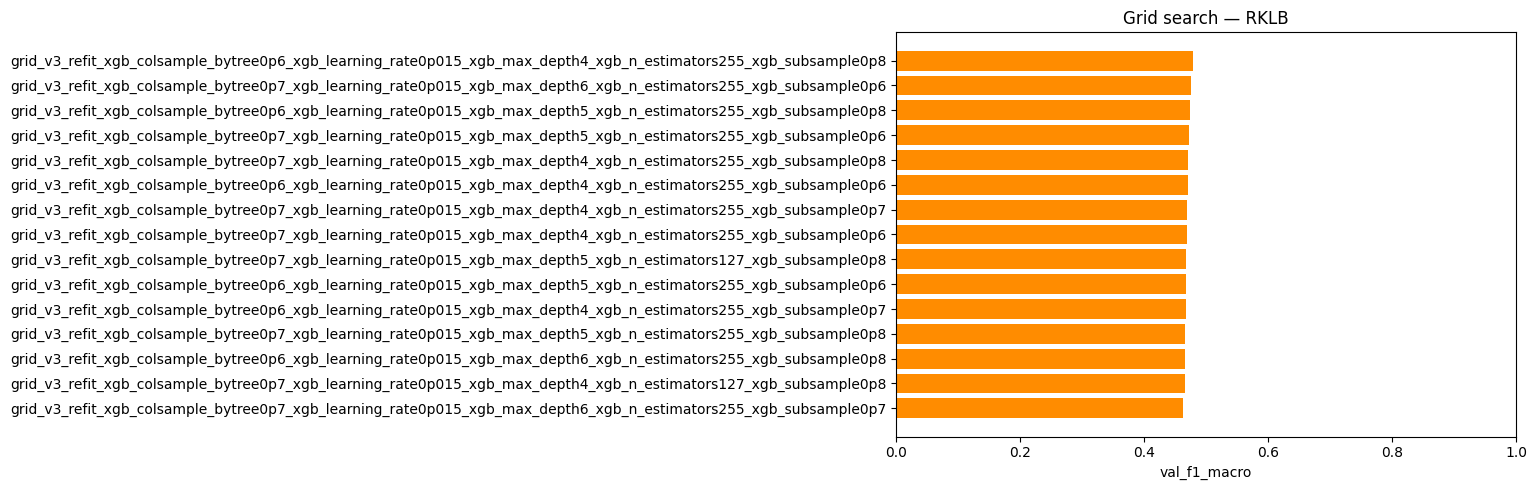

In [8]:
# Grid results chart (top combos by val_f1_macro)
import matplotlib.pyplot as plt

if RUN_MODE != "grid" or grid_df is None or not len(grid_df):
    print("No grid results to plot yet.")
elif "val_f1_macro" not in grid_df.columns:
    print("grid_df missing val_f1_macro")
else:
    ok_mask = grid_df["ok"] if "ok" in grid_df.columns else True
    plot_df = grid_df[ok_mask].dropna(subset=["val_f1_macro"]).copy()
    plot_df = plot_df.sort_values("val_f1_macro", ascending=True).tail(15)
    plot_df["label"] = plot_df["experiment_name"].fillna(plot_df.get("run_id", "")).astype(str)

    fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(plot_df))))
    ax.barh(plot_df["label"], plot_df["val_f1_macro"], color="darkorange")
    ax.set_xlabel("val_f1_macro")
    ax.set_title(f"Grid search — {cfg.symbol.upper()}")
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()

## All trials

Exports **`experiments.jsonl`** to a table (includes single-run and grid runs). Chart below uses the same log.

In [9]:
from sparkles.tracking.experiments_csv import experiments_log_path, export_experiments_to_csv

log_path = experiments_log_path(cfg, base_dir=REPO_ROOT)
csv_path = REPO_ROOT / "artifacts" / "training_log.csv"

if log_path.is_file():
    n = export_experiments_to_csv(log_path, csv_path, symbol_filter=cfg.symbol.upper())
    trials = pd.read_csv(csv_path)

    # Older log rows: stride lives under experiment_config.* in the CSV export
    if "label_entry_stride" not in trials.columns:
        nested = "experiment_config.label_entry_stride"
        if nested in trials.columns:
            trials["label_entry_stride"] = trials[nested]

    # Older log rows: train_accuracy only in metrics.json
    if "train_accuracy" not in trials.columns:
        trials["train_accuracy"] = pd.NA
    missing_acc = trials["train_accuracy"].isna()
    if missing_acc.any():
        sym_dir = REPO_ROOT / "artifacts" / cfg.symbol.upper()
        for idx in trials.index[missing_acc]:
            rid = str(trials.at[idx, "run_id"])
            mp = sym_dir / rid / "metrics.json"
            if mp.is_file():
                m = json.loads(mp.read_text(encoding="utf-8"))
                if "train_accuracy" in m:
                    trials.at[idx, "train_accuracy"] = m["train_accuracy"]

    cols = [
        c
        for c in [
            "logged_at_utc",
            "run_id",
            "train_experiment_name",
            "label_entry_stride",
            "model_type",
            "train_accuracy",
            "val_f1_macro",
            "val_f1_weighted",
            "val_accuracy",
            "train_n",
            "val_n",
        ]
        if c in trials.columns
    ]
    display(trials[cols].tail(10).sort_values("logged_at_utc", ascending=False))
    print(f"\n{len(trials)} total row(s) in {csv_path}")
else:
    print(f"No runs yet: {log_path}")

C:\Users\micha\AppData\Local\Temp\ipykernel_25032\2414455984.py:8: DtypeWarning: Columns (21,22,23,24,25,26,30,32,33,34,36,37,40,43,44,45,46,48,55,56,85,106,107,108,109,110,111,115,117,118,119,121,122,125,128,129,130,131,133,141) have mixed types. Specify dtype option on import or set low_memory=False.
  trials = pd.read_csv(csv_path)


,logged_at_utc,run_id,train_experiment_name,label_entry_stride,model_type,train_accuracy,val_f1_macro,val_f1_weighted,val_accuracy,train_n,val_n
8462,2026-06-27T05:45:50.365104+00:00,20260627T054550_323224Z,grid_v3_refit_xgb_colsample_bytree0p7_xgb_lear...,6.0,xgboost_classifier,0.886166,0.454297,0.555362,0.591812,53288,5838
8461,2026-06-27T05:45:40.613929+00:00,20260627T054540_581040Z,grid_v3_refit_xgb_colsample_bytree0p6_xgb_lear...,6.0,xgboost_classifier,0.885659,0.452056,0.553232,0.589243,53288,5838
8460,2026-06-27T05:45:31.218228+00:00,20260627T054531_175847Z,grid_v3_refit_xgb_colsample_bytree0p7_xgb_lear...,6.0,xgboost_classifier,0.888249,0.441204,0.542551,0.578965,53288,5838
8459,2026-06-27T05:45:21.408136+00:00,20260627T054521_366614Z,grid_v3_refit_xgb_colsample_bytree0p6_xgb_lear...,6.0,xgboost_classifier,0.886691,0.446593,0.548953,0.585303,53288,5838
8458,2026-06-27T05:45:12.240593+00:00,20260627T054512_200019Z,grid_v3_refit_xgb_colsample_bytree0p7_xgb_lear...,6.0,xgboost_classifier,0.889056,0.453787,0.554863,0.590613,53288,5838
8457,2026-06-27T05:45:02.669922+00:00,20260627T054502_628413Z,grid_v3_refit_xgb_colsample_bytree0p6_xgb_lear...,6.0,xgboost_classifier,0.891364,0.445125,0.546450,0.580507,53288,5838
8456,2026-06-27T05:44:53.370934+00:00,20260627T054453_336201Z,grid_v3_refit_xgb_colsample_bytree0p7_xgb_lear...,6.0,xgboost_classifier,0.813767,0.450288,0.547496,0.583590,53288,5838
8455,2026-06-27T05:44:45.869945+00:00,20260627T054445_839486Z,grid_v3_refit_xgb_colsample_bytree0p6_xgb_lear...,6.0,xgboost_classifier,0.813504,0.465590,0.566259,0.605344,53288,5838
8454,2026-06-27T05:44:38.393310+00:00,20260627T054438_358254Z,grid_v3_refit_xgb_colsample_bytree0p7_xgb_lear...,6.0,xgboost_classifier,0.819115,0.462618,0.565597,0.606543,53288,5838
8453,2026-06-27T05:44:30.844609+00:00,20260627T054430_810113Z,grid_v3_refit_xgb_colsample_bytree0p6_xgb_lear...,6.0,xgboost_classifier,0.819903,0.454124,0.560895,0.601405,53288,5838



8463 total row(s) in c:\Users\micha\PyProjects\Sparkles\artifacts\training_log.csv


C:\Users\micha\AppData\Local\Temp\ipykernel_25032\2259319111.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


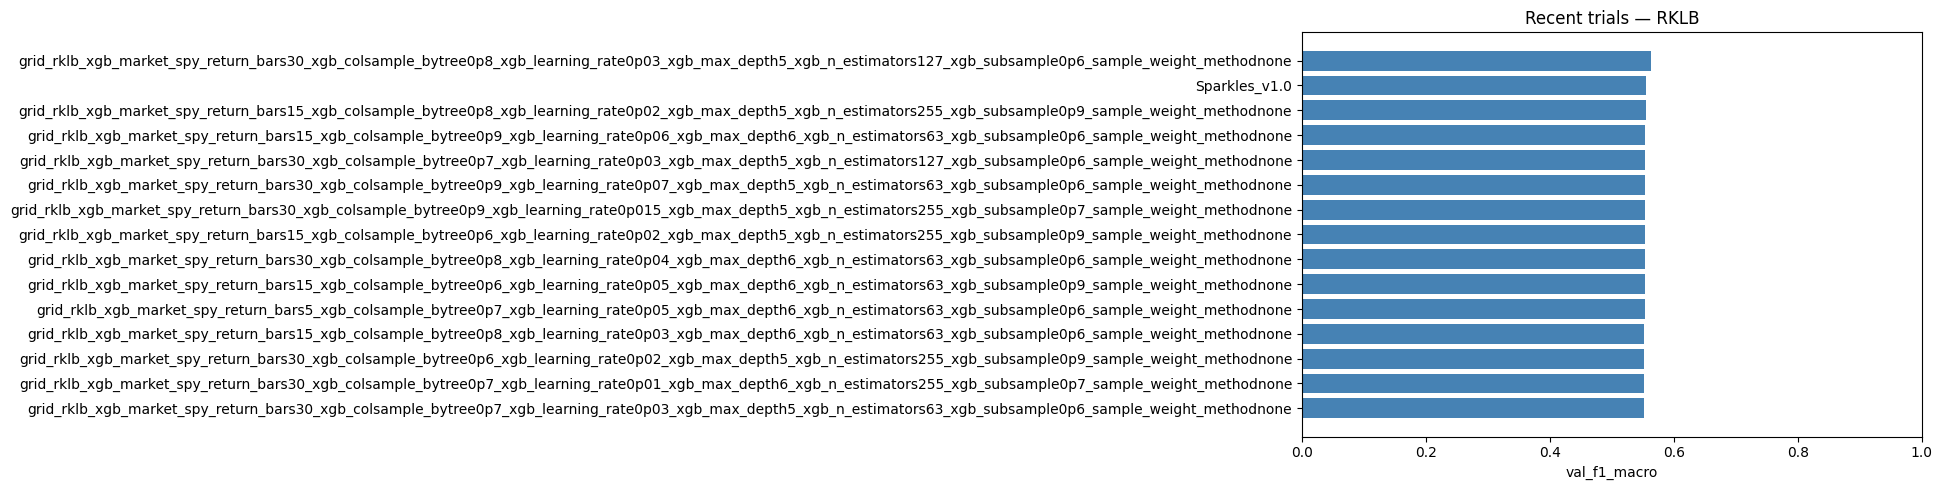

In [10]:
# Chart: prefer val_f1_macro (better for imbalanced labels), fall back to val_accuracy
import matplotlib.pyplot as plt

if log_path.is_file() and len(trials):
    plot_df = trials.copy()
    metric_col = "val_f1_macro" if "val_f1_macro" in plot_df.columns else "val_accuracy"
    plot_df = plot_df.dropna(subset=[metric_col])
    label_col = "train_experiment_name" if "train_experiment_name" in plot_df.columns else "run_id"
    plot_df["label"] = plot_df[label_col].fillna(plot_df["run_id"]).astype(str)
    plot_df = plot_df.sort_values(metric_col, ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(plot_df))))
    ax.barh(plot_df["label"], plot_df[metric_col], color="steelblue")
    ax.set_xlabel(metric_col)
    ax.set_title(f"Recent trials — {cfg.symbol.upper()}")
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()
else:
    print("Nothing to plot yet.")

In [11]:
# Per-class val metrics for the latest run (or the one you just trained)

def load_latest_metrics(symbol: str, artifacts_dir: str = "artifacts") -> tuple[Path, dict]:
    sym_dir = REPO_ROOT / artifacts_dir / symbol.upper()
    if not sym_dir.is_dir():
        raise FileNotFoundError(sym_dir)
    runs = sorted(p for p in sym_dir.iterdir() if p.is_dir() and (p / "metrics.json").is_file())
    if not runs:
        raise FileNotFoundError("No runs with metrics.json")
    latest = runs[-1]
    return latest, json.loads((latest / "metrics.json").read_text(encoding="utf-8"))

run_dir = last_run_dir if last_run_dir is not None else load_latest_metrics(cfg.symbol)[0]
metrics = json.loads((run_dir / "metrics.json").read_text(encoding="utf-8"))
report = metrics.get("classification_report_val", {})
rows = []
for name, stats in report.items():
    if isinstance(stats, dict) and "f1-score" in stats:
        rows.append({"class": name, **stats})
if rows:
    display(pd.DataFrame(rows).set_index("class")[["precision", "recall", "f1-score", "support"]])
    print("Run:", run_dir.name)
else:
    print("No classification_report_val in metrics.json")

,precision,recall,f1-score,support
class,,,,
stop_loss,0.593270,0.475627,0.527975,2113.0
take_profit,0.394052,0.121005,0.185153,876.0
vertical,0.628387,0.854686,0.724271,2849.0
macro avg,0.538570,0.483772,0.479133,5838.0
weighted avg,0.580515,0.607400,0.572328,5838.0


Run: 20260627T054325_076358Z


## Top 10 training runs (leaderboard)

All completed trains for **`cfg.symbol`** from **`experiments.jsonl`**, ranked by **`val_f1_macro`** (best → worst). Re-run after single or grid trains to refresh.

C:\Users\micha\AppData\Local\Temp\ipykernel_25032\823029134.py:16: DtypeWarning: Columns (21,22,23,24,25,26,30,32,33,34,36,37,40,43,44,45,46,48,55,56,85,106,107,108,109,110,111,115,117,118,119,121,122,125,128,129,130,131,133,141) have mixed types. Specify dtype option on import or set low_memory=False.
  all_runs = pd.read_csv(csv_path)


,rank,logged_at_utc,run_id,train_experiment_name,val_f1_macro,val_accuracy,val_f1_weighted,train_accuracy,train_n,val_n,model_type,label_entry_stride
2869,1,2026-06-23T03:23:29.450081+00:00,20260623T032329_428232Z,grid_rklb_xgb_market_spy_return_bars30_xgb_col...,0.562359,0.730197,0.736985,0.670777,33740,2083,xgboost_classifier,10.0
7805,2,2026-06-24T02:42:27.767350+00:00,20260624T024227_727510Z,Sparkles_v1.0,0.554925,0.730197,0.733429,0.670480,33740,2083,xgboost_classifier,10.0
4584,3,2026-06-23T05:52:53.995405+00:00,20260623T055253_969573Z,grid_rklb_xgb_market_spy_return_bars15_xgb_col...,0.554822,0.733077,0.737823,0.684736,33740,2083,xgboost_classifier,10.0
1719,4,2026-06-23T01:38:30.177210+00:00,20260623T013830_153355Z,grid_rklb_xgb_market_spy_return_bars15_xgb_col...,0.554276,0.729717,0.734556,0.709455,33740,2083,xgboost_classifier,10.0
2866,5,2026-06-23T03:23:14.919901+00:00,20260623T032314_897563Z,grid_rklb_xgb_market_spy_return_bars30_xgb_col...,0.553903,0.728277,0.734510,0.671340,33740,2083,xgboost_classifier,10.0
1912,6,2026-06-23T01:54:01.362355+00:00,20260623T015401_340321Z,grid_rklb_xgb_market_spy_return_bars30_xgb_col...,0.553501,0.726356,0.733415,0.679727,33740,2083,xgboost_classifier,10.0
4324,7,2026-06-23T05:27:13.803028+00:00,20260623T052713_777058Z,grid_rklb_xgb_market_spy_return_bars30_xgb_col...,0.552966,0.728277,0.735754,0.669947,33740,2083,xgboost_classifier,10.0
4578,8,2026-06-23T05:52:20.567973+00:00,20260623T055220_552971Z,grid_rklb_xgb_market_spy_return_bars15_xgb_col...,0.552952,0.730677,0.736773,0.681506,33740,2083,xgboost_classifier,10.0
1237,9,2026-06-23T00:58:59.664890+00:00,20260623T005859_641831Z,grid_rklb_xgb_market_spy_return_bars30_xgb_col...,0.552942,0.736438,0.739326,0.687048,33740,2083,xgboost_classifier,10.0
1506,10,2026-06-23T01:21:17.450087+00:00,20260623T012117_434541Z,grid_rklb_xgb_market_spy_return_bars15_xgb_col...,0.552917,0.728757,0.731699,0.692679,33740,2083,xgboost_classifier,10.0


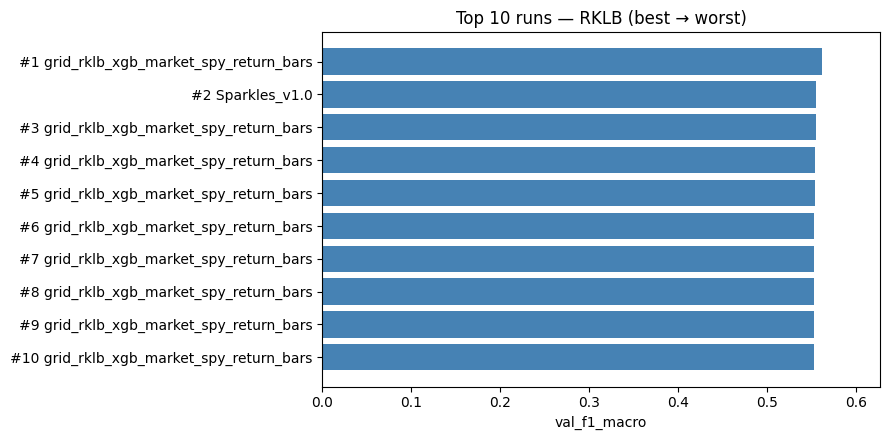


8463 total run(s) for RKLB; showing top 10 by val_f1_macro.


In [12]:
# Leaderboard — top 10 by validation metric (self-contained; re-exports log → CSV)

from sparkles.tracking.experiments_csv import experiments_log_path, export_experiments_to_csv

import matplotlib.pyplot as plt

TOP_N = 10
LEADERBOARD_METRIC = "val_f1_macro"  # preferred for imbalanced barrier labels

log_path = experiments_log_path(cfg, base_dir=REPO_ROOT)
if not log_path.is_file():
    print(f"No training log yet: {log_path}\nRun sparkles train or the Train cell above first.")
else:
    csv_path = REPO_ROOT / "artifacts" / "training_log.csv"
    export_experiments_to_csv(log_path, csv_path, symbol_filter=cfg.symbol.upper())
    all_runs = pd.read_csv(csv_path)

    metric = LEADERBOARD_METRIC if LEADERBOARD_METRIC in all_runs.columns else "val_accuracy"
    scored = all_runs.dropna(subset=[metric]).copy()

    if scored.empty:
        print(f"No runs with {metric!r} for {cfg.symbol.upper()}.")
    else:
        top = scored.sort_values(metric, ascending=False).head(TOP_N).copy()
        top.insert(0, "rank", range(1, len(top) + 1))

        show_cols = [
            c
            for c in [
                "rank",
                "logged_at_utc",
                "run_id",
                "train_experiment_name",
                metric,
                "val_accuracy",
                "val_f1_weighted",
                "train_accuracy",
                "train_n",
                "val_n",
                "model_type",
                "label_entry_stride",
            ]
            if c in top.columns
        ]
        display(top[show_cols])

        plot_df = top.iloc[::-1]  # best at top of chart
        labels = plot_df["train_experiment_name"].fillna(plot_df["run_id"]).astype(str)
        labels = [f"#{int(r)} {n[:36]}" for r, n in zip(plot_df["rank"], labels)]

        fig, ax = plt.subplots(figsize=(9, max(3.5, 0.45 * len(plot_df))))
        ax.barh(labels, plot_df[metric], color="steelblue")
        ax.set_xlabel(metric)
        ax.set_title(f"Top {len(top)} runs — {cfg.symbol.upper()} (best → worst)")
        ax.set_xlim(0, min(1.0, float(plot_df[metric].max()) * 1.08 + 0.02))
        plt.tight_layout()
        plt.show()

        print(
            f"\n{len(all_runs)} total run(s) for {cfg.symbol.upper()}; "
            f"showing top {len(top)} by {metric}."
        )